# Error Analysis — gcn_vs_cnn

Analiza predykcji modelu: z jakimi cząsteczkami model sobie radzi dobrze, a z jakimi ma problemy.

**Sekcje:**
1. Ładowanie modelu i uruchomienie inferencji na zbiorze testowym
2. Obliczenie właściwości molekularnych (RDKit)
3. Analiza błędów (FP, FN) vs poprawnych predykcji (TP, TN)
4. Rozkłady pewności modelu
5. Analiza właściwości molekularnych per kategoria
6. Najgorsze pomyłki (high-confidence errors)
7. Analiza per białko

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# RDKit for molecular property computation
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors

# Project imports
from data.transform import train_val_test_split_scaffold
from datasets.dti_dataset import DTIDataset, build_collate_fn
from main import (
    ROOT_DIR,
    MultimodalDTI,
    build_fusion,
    build_protein_components,
    build_smiles_components,
    load_data,
)
from processing.smiles.graph_processor import GraphProcessor

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
})

MODEL_NAME = "gcn_vs_cnn"
CONFIG_PATH = ROOT_DIR / "configs" / f"{MODEL_NAME}.yaml"
CHECKPOINT_PATH = ROOT_DIR / "checkpoints" / f"{MODEL_NAME}.pt"

print(f"Config:     {CONFIG_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

/home/kappy/Repos/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kappy/Repos/Multimodal-models-for-predicting-drug-target-interactions/.venv/lib/python3.11/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Config:     /home/kappy/Repos/Multimodal-models-for-predicting-drug-target-interactions/src/configs/gcn_vs_cnn.yaml
Checkpoint: /home/kappy/Repos/Multimodal-models-for-predicting-drug-target-interactions/src/checkpoints/gcn_vs_cnn.pt


## 1. Ładowanie modelu i inferencja

In [2]:
# Load config
with CONFIG_PATH.open() as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data"]
train_cfg = cfg["training"]

# Load data and split
df = load_data(data_cfg)
print(f"Dataset: {df.shape}")

split_ratios = data_cfg.get("split_ratios", [0.7, 0.1, 0.2])
train_df, val_df, test_df = train_val_test_split_scaffold(df, proportions=split_ratios)
print(f"Train: {train_df.height}  Val: {val_df.height}  Test: {test_df.height}")

Loading clean data from: /home/kappy/Repos/Multimodal-models-for-predicting-drug-target-interactions/src/datasets/clean.parquet
Dataset: (451858, 5)
Train: 317060  Val: 44695  Test: 90103


In [3]:
# Build model components
smiles_processors, smiles_encoders = build_smiles_components(cfg)
protein_processors, protein_encoders = build_protein_components(cfg)

# Filter invalid SMILES for GCN
for proc in smiles_processors:
    if isinstance(proc, GraphProcessor):
        all_smiles = (
            train_df["Ligand SMILES"].unique().sort().to_list()
            + val_df["Ligand SMILES"].unique().sort().to_list()
            + test_df["Ligand SMILES"].unique().sort().to_list()
        )
        proc.build_cache(list(dict.fromkeys(all_smiles)))
        valid = proc.valid_smiles
        train_df = train_df.filter(pl.col("Ligand SMILES").is_in(valid))
        val_df = val_df.filter(pl.col("Ligand SMILES").is_in(valid))
        test_df = test_df.filter(pl.col("Ligand SMILES").is_in(valid))

print(f"Test after filtering: {test_df.height} samples")

Building graph cache for 236379 SMILES...


100%|██████████| 236379/236379 [01:05<00:00, 3613.89it/s]


Test after filtering: 90103 samples


In [4]:
# Build model and load checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

total_smiles_dim = sum(e.output_dim for e in smiles_encoders)
total_protein_dim = sum(e.output_dim for e in protein_encoders)
fusion = build_fusion(cfg, total_smiles_dim, total_protein_dim)
model = MultimodalDTI(smiles_encoders, protein_encoders, fusion)
model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
)
model = model.to(device)
model.eval()
print("Model loaded ✓")

Device: cuda
Model loaded ✓


In [5]:
# Build test DataLoader
batch_size = train_cfg.get("batch_size", 256)
num_workers = train_cfg.get("num_workers", 4)
if "OMP_NUM_THREADS" in os.environ:
    num_workers = 0

test_ds = DTIDataset(
    smiles_list=test_df["Ligand SMILES"].to_list(),
    sequence_list=test_df["Full_Protein_Sequence"].to_list(),
    labels=test_df["is_active"].cast(pl.Float64).to_list(),
    smiles_processors=smiles_processors,
    protein_processors=protein_processors,
)
collate_fn = build_collate_fn(smiles_processors, protein_processors)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)
print(f"Test loader: {len(test_loader)} batches × {batch_size}")

Test loader: 176 batches × 512


In [6]:
def _to_device(obj, device):
    if isinstance(obj, (list, tuple)):
        return type(obj)(_to_device(item, device) for item in obj)
    if hasattr(obj, "to"):
        return obj.to(device)
    if isinstance(obj, dict):
        return {k: _to_device(v, device) for k, v in obj.items()}
    return obj


# Run inference — collect per-sample predictions
all_labels = []
all_probs = []

with torch.no_grad():
    for smiles_batch, protein_batch, y in tqdm(test_loader, desc="Inference"):
        smiles_batch = _to_device(smiles_batch, device)
        protein_batch = _to_device(protein_batch, device)
        logits = model(smiles_batch, protein_batch).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(y.numpy().tolist())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)

print(f"Inference done: {len(all_labels)} samples")
print(f"Accuracy: {(all_preds == all_labels).mean():.4f}")

Inference: 100%|██████████| 176/176 [00:11<00:00, 15.89it/s]

Inference done: 90103 samples
Accuracy: 0.8105


## 2. Obliczenie właściwości molekularnych (RDKit)

In [7]:
smiles_list = test_df["Ligand SMILES"].to_list()
protein_list = test_df["Full_Protein_Sequence"].to_list()

def compute_mol_properties(smiles: str) -> dict:
    """Compute a set of molecular descriptors using RDKit."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {
            "MW": np.nan, "LogP": np.nan, "TPSA": np.nan,
            "HeavyAtomCount": np.nan, "NumRotatableBonds": np.nan,
            "NumRings": np.nan, "NumAromaticRings": np.nan,
            "NumHBondDonors": np.nan, "NumHBondAcceptors": np.nan,
            "FractionCSP3": np.nan, "SMILES_len": len(smiles),
        }
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "NumRings": rdMolDescriptors.CalcNumRings(mol),
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "NumHBondDonors": Lipinski.NumHDonors(mol),
        "NumHBondAcceptors": Lipinski.NumHAcceptors(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "SMILES_len": len(smiles),
    }


print("Computing molecular properties ...")
props = [compute_mol_properties(s) for s in tqdm(smiles_list, desc="RDKit")]
props_df = pl.DataFrame(props)
print(f"Done — {props_df.shape}")

Computing molecular properties ...


RDKit: 100%|██████████| 90103/90103 [00:38<00:00, 2334.67it/s]

Done — (90103, 11)


In [8]:
# Build the full results DataFrame
results = pl.DataFrame({
    "smiles": smiles_list[:len(all_labels)],
    "protein_seq": protein_list[:len(all_labels)],
    "protein_len": [len(p) for p in protein_list[:len(all_labels)]],
    "true_label": all_labels.astype(int),
    "pred_prob": all_probs,
    "pred_label": all_preds,
})

# Add prediction category
results = results.with_columns(
    pl.when((pl.col("true_label") == 1) & (pl.col("pred_label") == 1))
      .then(pl.lit("TP"))
      .when((pl.col("true_label") == 0) & (pl.col("pred_label") == 0))
      .then(pl.lit("TN"))
      .when((pl.col("true_label") == 0) & (pl.col("pred_label") == 1))
      .then(pl.lit("FP"))
      .otherwise(pl.lit("FN"))
      .alias("category"),
    (pl.col("true_label") == pl.col("pred_label")).alias("correct"),
    (pl.col("pred_prob") - 0.5).abs().alias("confidence"),
)

# Concat molecular properties
results = pl.concat([results, props_df[:len(all_labels)]], how="horizontal")

print("Category distribution:")
print(results["category"].value_counts().sort("category"))
results.head(5)

Category distribution:
shape: (4, 2)
┌──────────┬───────┐
│ category ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ FN       ┆ 8786  │
│ FP       ┆ 8289  │
│ TN       ┆ 37034 │
│ TP       ┆ 35994 │
└──────────┴───────┘


smiles,protein_seq,protein_len,true_label,pred_prob,pred_label,category,correct,confidence,MW,LogP,TPSA,HeavyAtomCount,NumRotatableBonds,NumRings,NumAromaticRings,NumHBondDonors,NumHBondAcceptors,FractionCSP3,SMILES_len
str,str,i64,i64,f64,i64,str,bool,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64
"""OCC1OC(O)C(Oc2c(O)c3c(cc(O)cc3…","""MDHQDPYSVQATAAIAAAITFLILFTIFGN…",450,0,0.000061,0,"""TN""",true,0.499939,464.379,-0.5873,210.51,33,4,4,1,8,12,0.285714,59
"""Oc1cccc2c1O[C@@H]1CC[C@@H]3C[C…","""MDSPIQIFRGEPGPTCAPSACLPPNSSAWF…",380,0,0.471307,0,"""TN""",true,0.028693,335.447,3.8919,32.7,25,3,5,2,1,3,0.454545,48
"""Cc1c(CO)oc2cccc3n(cc1c23)S(=O)…","""MDVLSPGQGNNTTSPPAPFETGGNTTGISD…",422,0,0.002757,0,"""TN""",true,0.497243,341.388,2.994,68.53,24,3,4,3,1,5,0.111111,42
"""OC[C@H]1O[C@H]([C@H](O)[C@@H]1…","""MPPSISAFQAAYIGIEVLIALVSVPGNVLV…",326,1,0.695201,1,"""TP""",true,0.195201,361.402,0.0383,125.55,26,4,5,2,4,9,0.705882,59
"""C[C@H]1CN(CC[C@@]1(C)c2cccc(c2…","""MDSSTGPGNTSDCSDPLAQASCSPAPGSWL…",398,1,0.624743,1,"""TP""",true,0.124743,465.638,3.5526,84.83,34,6,4,2,4,5,0.535714,73


## 3. Rozkład pewności modelu

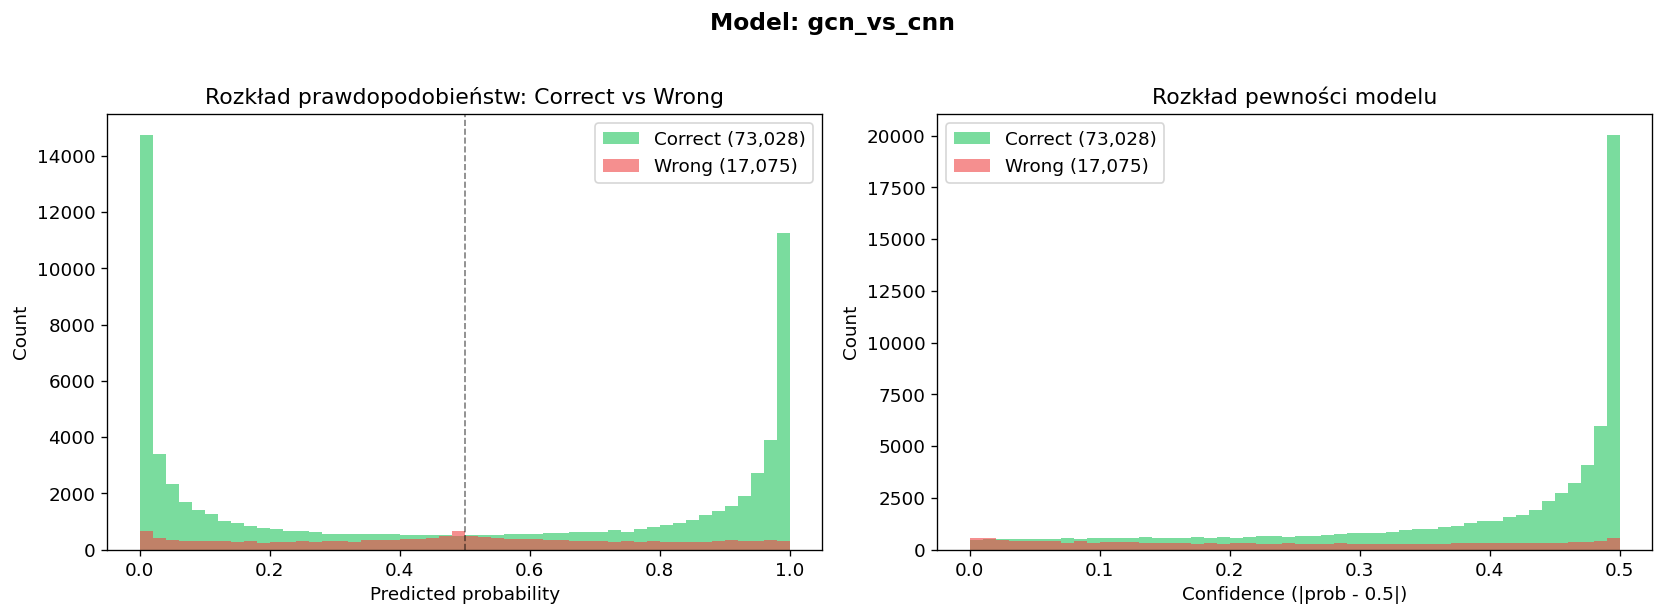

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Histogram prawdopodobieństw — poprawne vs błędne
ax = axes[0]
correct_probs = results.filter(pl.col("correct"))["pred_prob"].to_numpy()
wrong_probs = results.filter(~pl.col("correct"))["pred_prob"].to_numpy()

ax.hist(correct_probs, bins=50, alpha=0.6, label=f"Correct ({len(correct_probs):,})", color="#22c55e")
ax.hist(wrong_probs, bins=50, alpha=0.6, label=f"Wrong ({len(wrong_probs):,})", color="#ef4444")
ax.axvline(0.5, color="k", linestyle="--", lw=1, alpha=0.5)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Count")
ax.set_title("Rozkład prawdopodobieństw: Correct vs Wrong")
ax.legend()

# (b) Histogram pewności (|prob - 0.5|) — poprawne vs błędne
ax = axes[1]
correct_conf = results.filter(pl.col("correct"))["confidence"].to_numpy()
wrong_conf = results.filter(~pl.col("correct"))["confidence"].to_numpy()

ax.hist(correct_conf, bins=50, alpha=0.6, label=f"Correct ({len(correct_conf):,})", color="#22c55e")
ax.hist(wrong_conf, bins=50, alpha=0.6, label=f"Wrong ({len(wrong_conf):,})", color="#ef4444")
ax.set_xlabel("Confidence (|prob - 0.5|)")
ax.set_ylabel("Count")
ax.set_title("Rozkład pewności modelu")
ax.legend()

fig.suptitle(f"Model: {MODEL_NAME}", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

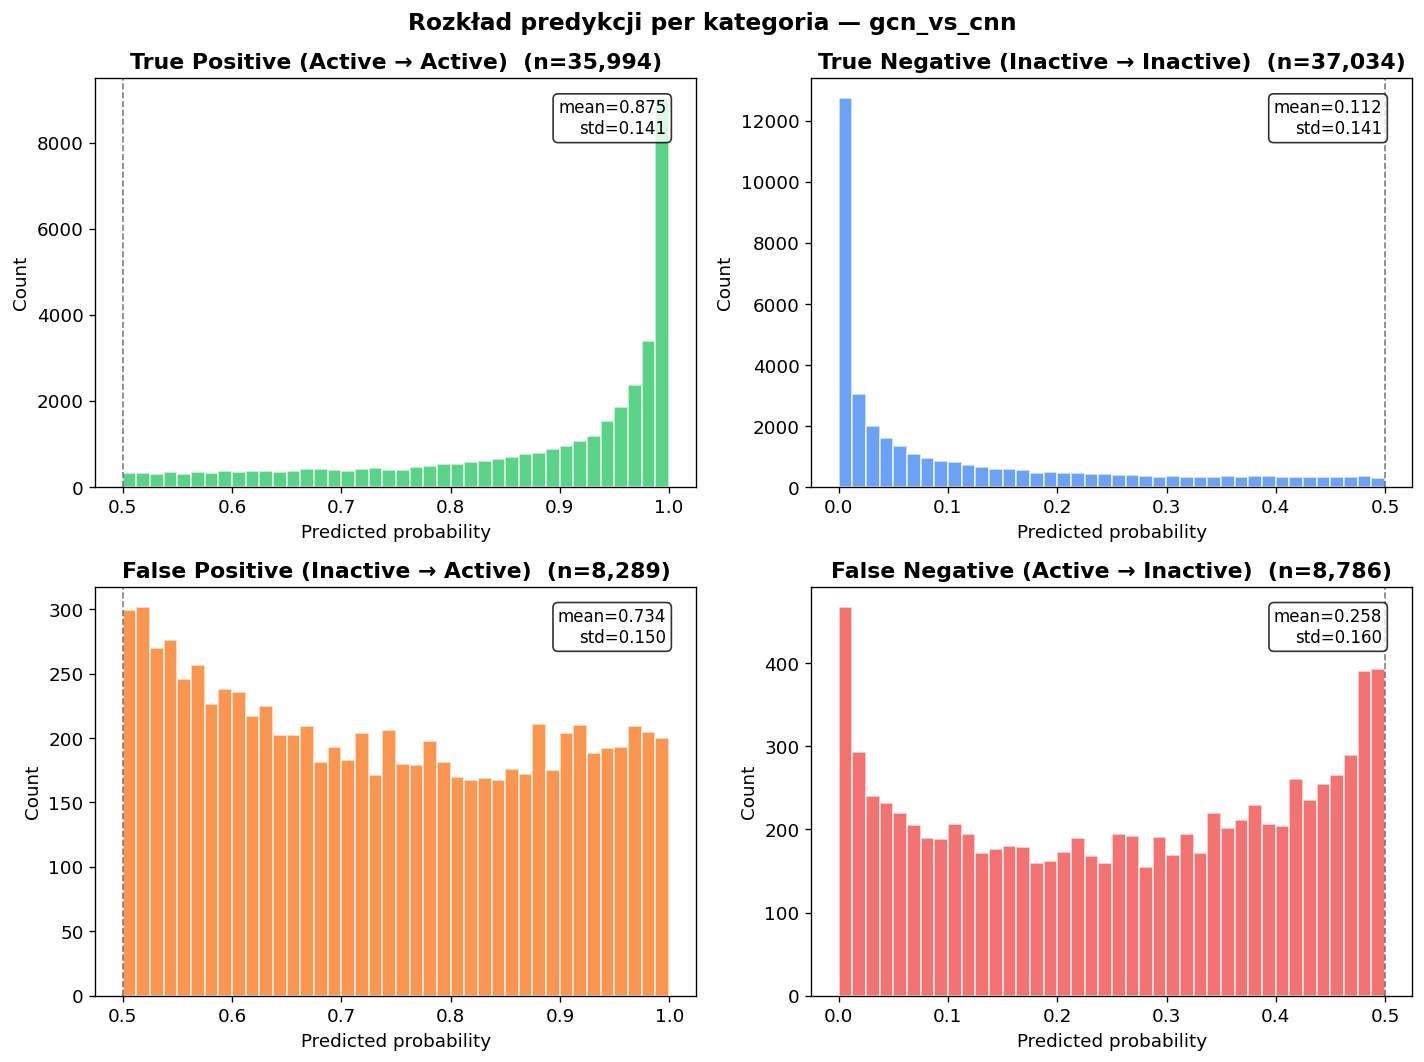

In [10]:
# Rozkład prawdopodobieństw per kategoria (TP, TN, FP, FN)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
colors = {"TP": "#22c55e", "TN": "#3b82f6", "FP": "#f97316", "FN": "#ef4444"}
titles = {
    "TP": "True Positive (Active → Active)",
    "TN": "True Negative (Inactive → Inactive)",
    "FP": "False Positive (Inactive → Active)",
    "FN": "False Negative (Active → Inactive)",
}

for ax, cat in zip(axes.flat, ["TP", "TN", "FP", "FN"]):
    subset = results.filter(pl.col("category") == cat)
    probs = subset["pred_prob"].to_numpy()
    ax.hist(probs, bins=40, color=colors[cat], alpha=0.75, edgecolor="white")
    ax.axvline(0.5, color="k", linestyle="--", lw=1, alpha=0.5)
    ax.set_title(f"{titles[cat]}  (n={len(probs):,})", fontweight="bold")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")
    if len(probs) > 0:
        ax.text(0.95, 0.95, f"mean={probs.mean():.3f}\nstd={probs.std():.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

fig.suptitle(f"Rozkład predykcji per kategoria — {MODEL_NAME}", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Analiza właściwości molekularnych — correct vs wrong

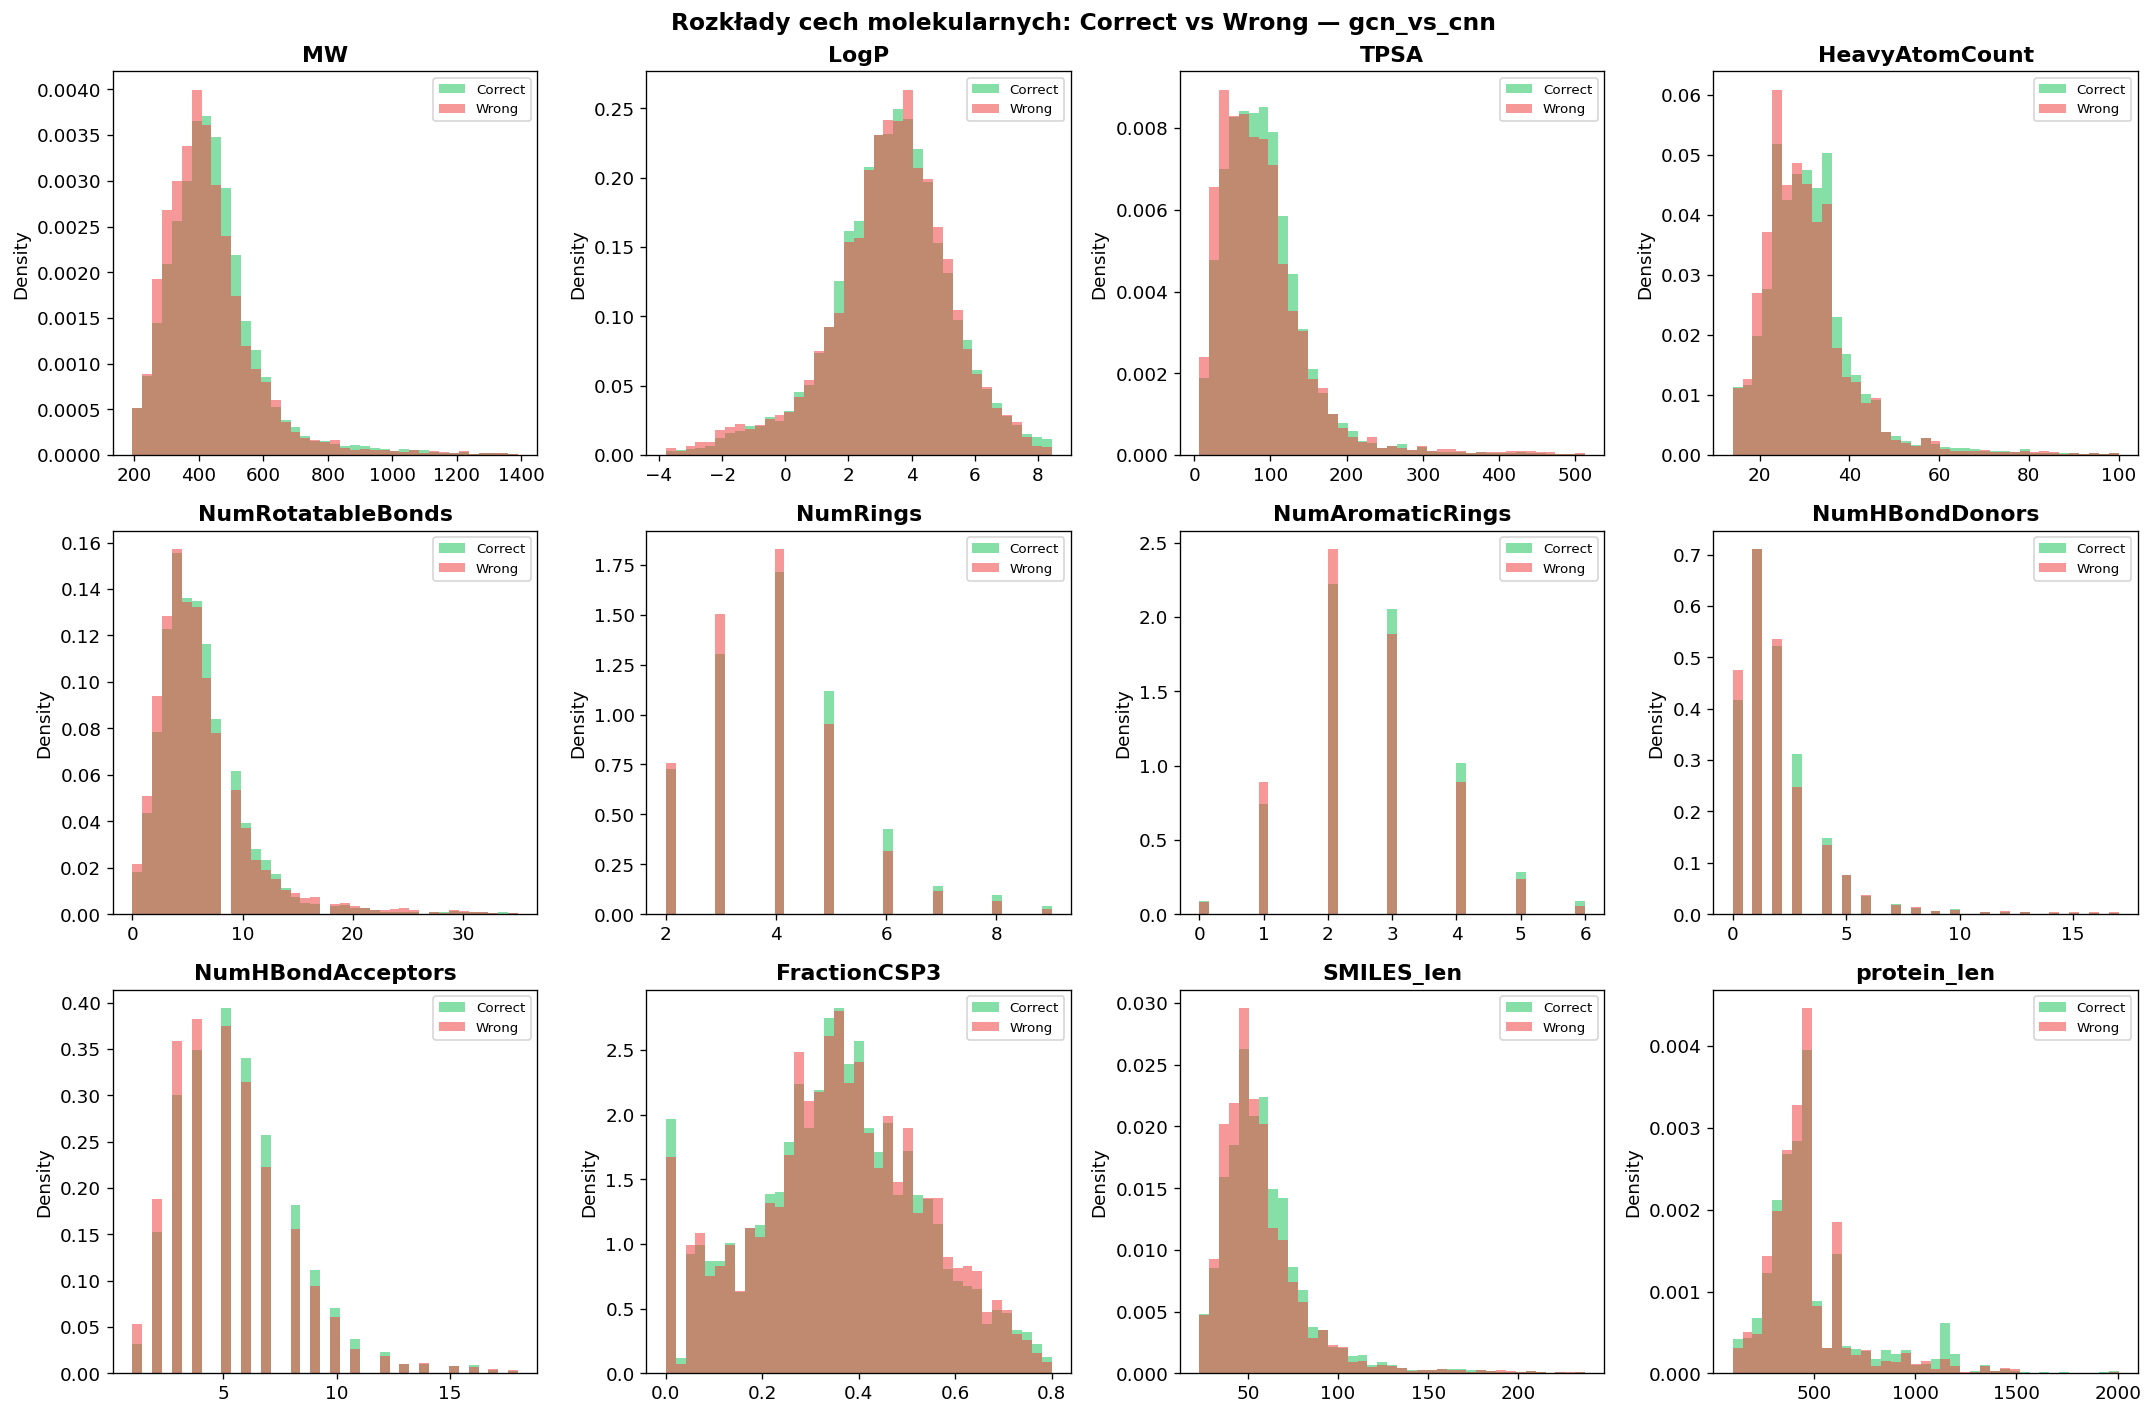

In [11]:
mol_features = [
    "MW", "LogP", "TPSA", "HeavyAtomCount", "NumRotatableBonds",
    "NumRings", "NumAromaticRings", "NumHBondDonors", "NumHBondAcceptors",
    "FractionCSP3", "SMILES_len", "protein_len",
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, feat in zip(axes.flat, mol_features):
    correct_vals = results.filter(pl.col("correct"))[feat].drop_nulls().to_numpy()
    wrong_vals = results.filter(~pl.col("correct"))[feat].drop_nulls().to_numpy()

    # Use shared bin edges
    all_vals = np.concatenate([correct_vals, wrong_vals])
    bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 40)

    ax.hist(correct_vals, bins=bins, alpha=0.55, label="Correct", color="#22c55e", density=True)
    ax.hist(wrong_vals, bins=bins, alpha=0.55, label="Wrong", color="#ef4444", density=True)
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

fig.suptitle(f"Rozkłady cech molekularnych: Correct vs Wrong — {MODEL_NAME}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [12]:
# Statystyki per kategoria
stats_rows = []
for cat in ["TP", "TN", "FP", "FN"]:
    subset = results.filter(pl.col("category") == cat)
    row = {"category": cat, "count": subset.height}
    for feat in mol_features:
        vals = subset[feat].drop_nulls()
        if vals.len() > 0:
            row[f"{feat}_mean"] = round(vals.mean(), 2)
            row[f"{feat}_median"] = round(vals.median(), 2)
    stats_rows.append(row)

stats_df = pl.DataFrame(stats_rows)
print("Średnie właściwości molekularne per kategoria:")
stats_df

Średnie właściwości molekularne per kategoria:


category,count,MW_mean,MW_median,LogP_mean,LogP_median,TPSA_mean,TPSA_median,HeavyAtomCount_mean,HeavyAtomCount_median,NumRotatableBonds_mean,NumRotatableBonds_median,NumRings_mean,NumRings_median,NumAromaticRings_mean,NumAromaticRings_median,NumHBondDonors_mean,NumHBondDonors_median,NumHBondAcceptors_mean,NumHBondAcceptors_median,FractionCSP3_mean,FractionCSP3_median,SMILES_len_mean,SMILES_len_median,protein_len_mean,protein_len_median
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""TP""",35994,494.2,447.45,3.54,3.65,105.07,88.62,34.98,32.0,7.31,6.0,4.4,4.0,2.81,3.0,2.33,2.0,6.23,6.0,0.38,0.38,67.29,58.0,540.85,425.0
"""TN""",37034,423.51,401.52,3.08,3.2,93.68,80.0,29.98,28.0,6.25,5.0,3.73,4.0,2.57,2.0,2.12,2.0,5.47,5.0,0.34,0.35,57.32,51.0,509.62,443.0
"""FP""",8289,472.04,419.28,3.24,3.5,103.8,80.04,33.36,30.0,7.2,5.0,4.03,4.0,2.6,2.0,2.43,1.0,5.86,5.0,0.37,0.36,64.71,53.0,493.99,425.0
"""FN""",8786,446.21,400.45,3.09,3.36,97.97,77.1,31.41,28.0,6.73,5.0,3.77,4.0,2.51,2.0,2.29,1.0,5.57,5.0,0.36,0.36,60.86,51.0,479.42,422.0


## 5. Analiza per kategoria błędu (FP vs FN)

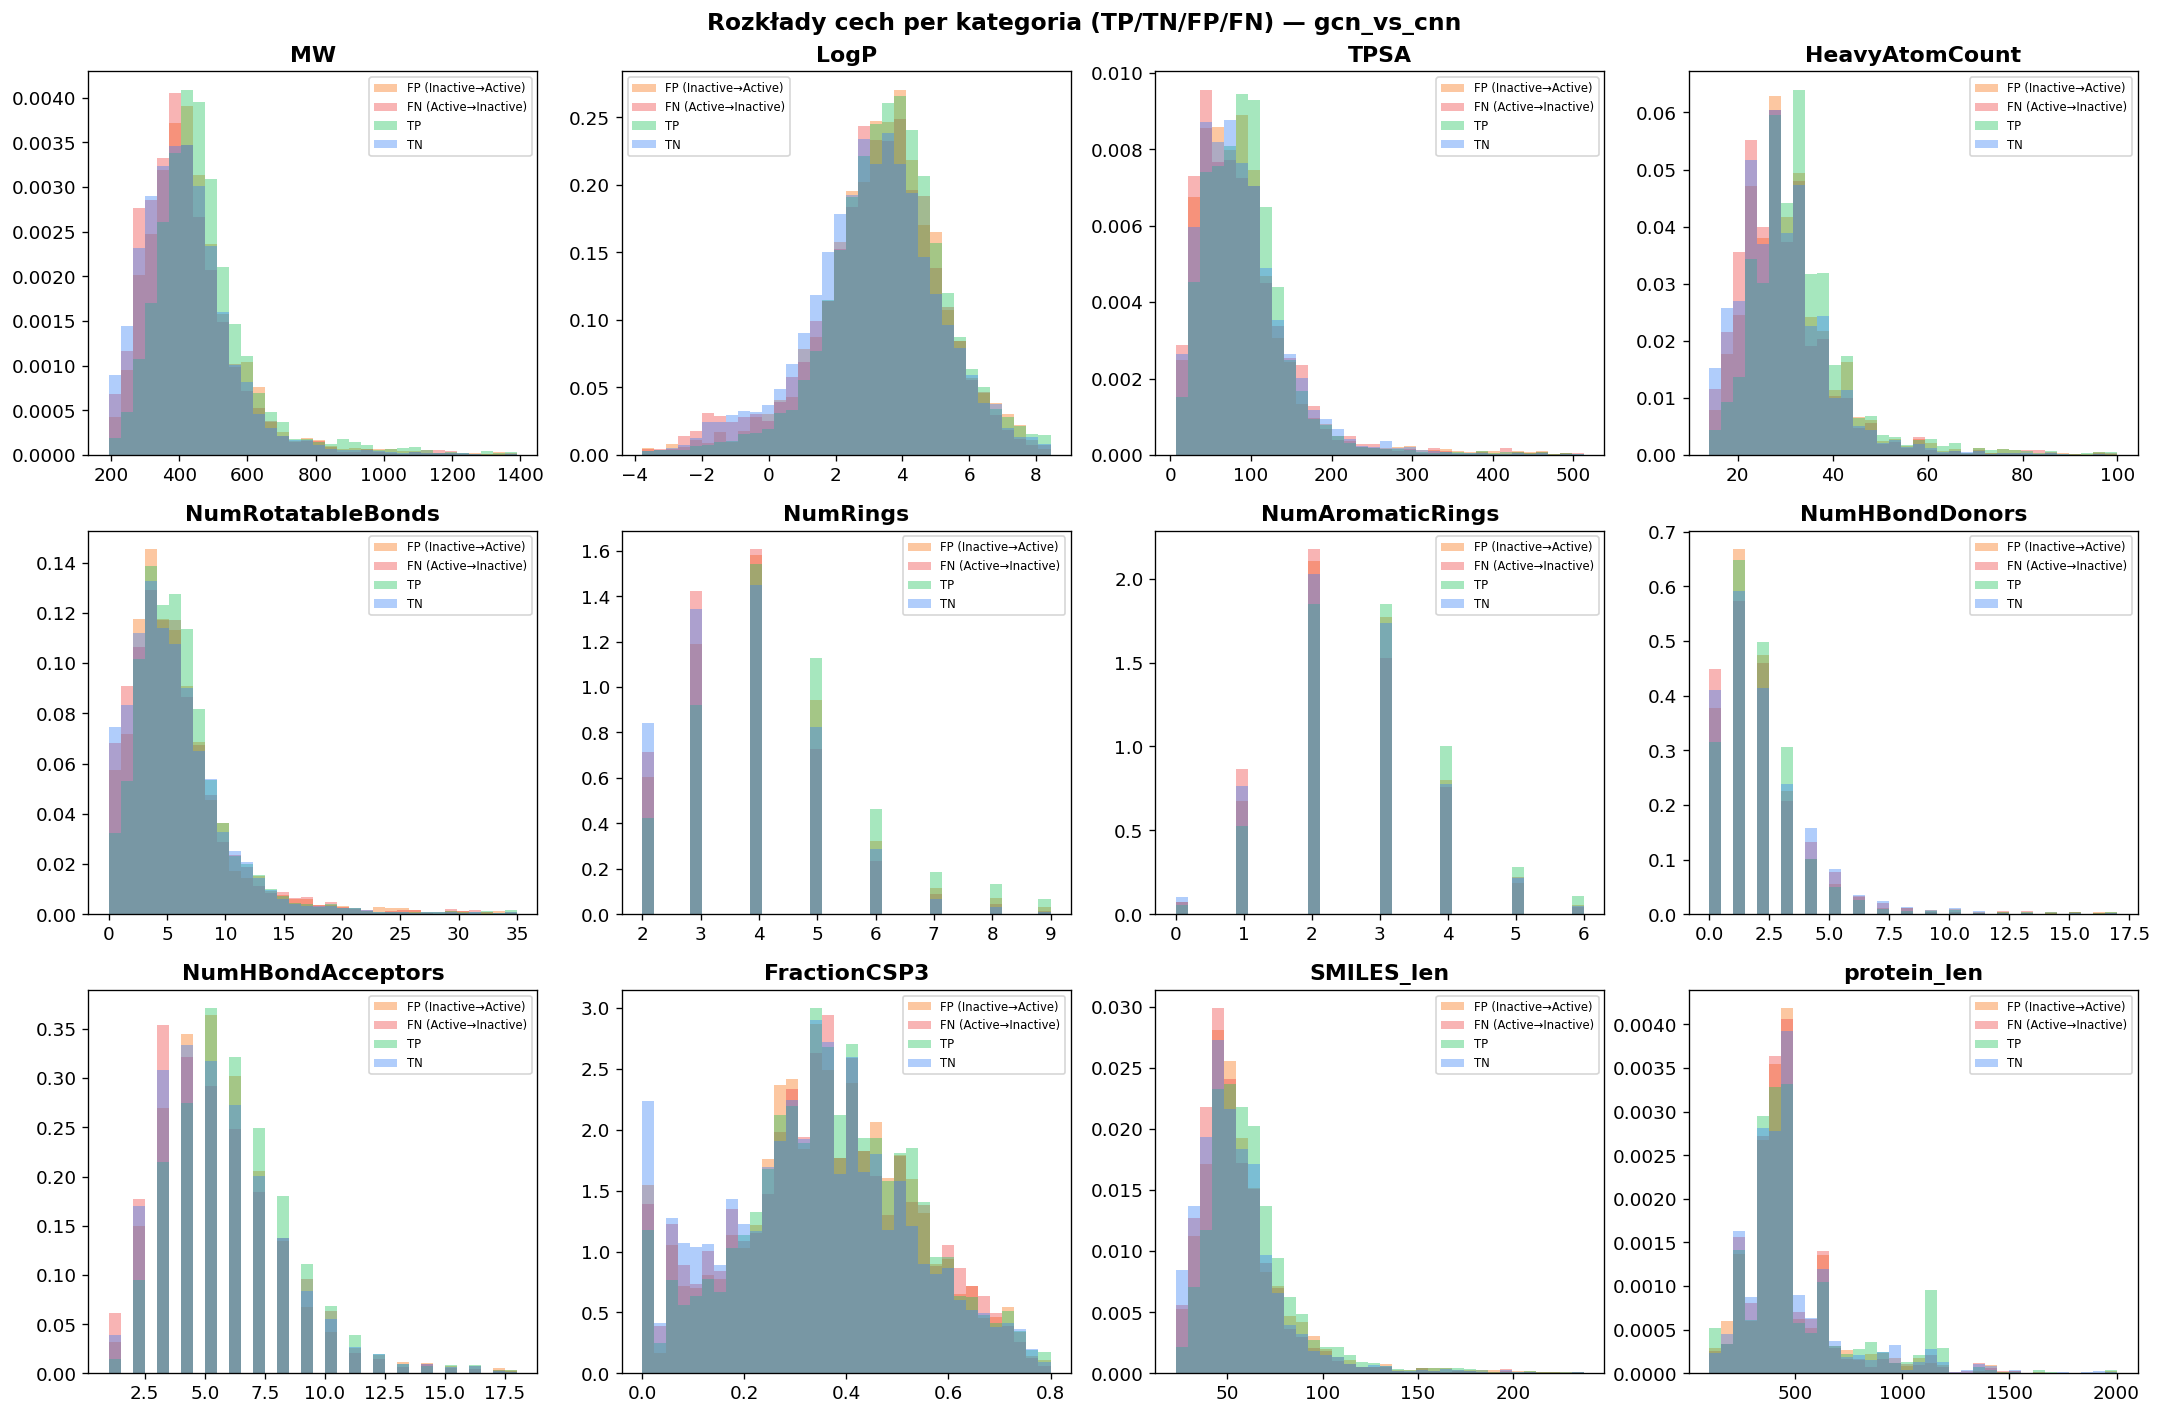

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, feat in zip(axes.flat, mol_features):
    for cat, color, label in [("FP", "#f97316", "FP (Inactive→Active)"),
                               ("FN", "#ef4444", "FN (Active→Inactive)"),
                               ("TP", "#22c55e", "TP"),
                               ("TN", "#3b82f6", "TN")]:
        vals = results.filter(pl.col("category") == cat)[feat].drop_nulls().to_numpy()
        if len(vals) > 0:
            all_data = results[feat].drop_nulls().to_numpy()
            bins = np.linspace(np.percentile(all_data, 1), np.percentile(all_data, 99), 35)
            ax.hist(vals, bins=bins, alpha=0.4, label=label, color=color, density=True)
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=7)

fig.suptitle(f"Rozkłady cech per kategoria (TP/TN/FP/FN) — {MODEL_NAME}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Najgorsze pomyłki (high-confidence errors)

In [14]:
# Top 20 najgorzych False Positives (model pewny Active, a naprawdę Inactive)
top_fp = (
    results
    .filter(pl.col("category") == "FP")
    .sort("pred_prob", descending=True)
    .head(20)
    .select(["smiles", "pred_prob", "confidence", "MW", "LogP", "TPSA",
             "HeavyAtomCount", "NumRings", "protein_len"])
)
print("Top 20 False Positives (highest confidence):")
top_fp

Top 20 False Positives (highest confidence):


smiles,pred_prob,confidence,MW,LogP,TPSA,HeavyAtomCount,NumRings,protein_len
str,f64,f64,f64,f64,f64,i64,i64,i64
"""COC(=O)C1CCN(CC1)c1ncc(s1)C(=O…",0.999868,0.499868,403.464,2.05707,130.63,28,3,1019
"""NC(=N)Nc1ccc(OC(=O)c2cnc(s2)N2…",0.999658,0.499658,389.437,1.96867,141.63,27,3,1019
"""CCCCn1nc(s\c1=N/C(=O)c1cc(ccc1…",0.9995,0.4995,455.55,5.6098,71.64,31,2,360
"""COc1cc(ccc1O[C@@H](CN(C)C)c1cc…",0.999221,0.499221,489.601,4.85112,89.47,35,4,564
"""C[n+]1ccc(c(F)c1)-c1c2ccc(n2)c…",0.99893,0.49893,750.804,7.178,72.88,56,9,633
…,…,…,…,…,…,…,…,…
"""FC(F)(F)Cn1cc(cn1)-c1cc2n(ncc2…",0.998307,0.498307,468.487,3.5736,76.69,34,6,311
"""[H][C@]12Cc3ccc(O)c4OC5[C@](CC…",0.9983,0.4983,425.569,3.3876,62.16,31,8,398
"""COCc1c(cnn1C1CCCCC1)-c1nc(no1)…",0.998259,0.498259,454.527,4.6331,112.5,33,4,382


In [15]:
# Top 20 najgorszych False Negatives (model pewny Inactive, a naprawdę Active)
top_fn = (
    results
    .filter(pl.col("category") == "FN")
    .sort("pred_prob")  # lowest prob = highest confidence of being inactive
    .head(20)
    .select(["smiles", "pred_prob", "confidence", "MW", "LogP", "TPSA",
             "HeavyAtomCount", "NumRings", "protein_len"])
)
print("Top 20 False Negatives (highest confidence):")
top_fn

Top 20 False Negatives (highest confidence):


smiles,pred_prob,confidence,MW,LogP,TPSA,HeavyAtomCount,NumRings,protein_len
str,f64,f64,f64,f64,f64,i64,i64,i64
"""Cc1ccc(-c2nc3cc(C(=N)N)ccc3[nH…",1.1789e-8,0.5,251.293,2.21739,91.44,19,3,686
"""Cc1ccnc(-c2nc3cc(C(=N)N)ccc3[n…",2.6593e-8,0.5,251.293,2.21739,91.44,19,3,686
"""CCOc1ccnc(-c2nc3cc(C(=N)N)ccc3…",3.5810e-8,0.5,281.319,2.30767,100.67,21,3,686
"""Cc1cc(N)nc(C[C@H]2CNC[C@@H]2NC…",3.7555e-8,0.5,353.514,1.52462,75.0,26,3,1144
"""Cc1cccc(-c2nc3cc(C(=N)N)ccc3[n…",4.9342e-8,0.5,251.293,2.21739,91.44,19,3,686
…,…,…,…,…,…,…,…,…
"""COc1ccc(COC(=O)C2C(C(C2c2ccccc…",0.000018,0.499982,415.465,3.3019,75.66,31,4,133
"""Cc1cnc(c(c1OC)C)Cn2cnc3c2nc(nc…",0.00002,0.49998,318.768,2.13064,91.74,22,3,704
"""CC(C(O)=O)c1ccc2c(c1)[nH]c1ccc…",0.000021,0.499979,273.719,4.1626,53.09,19,3,599


## 7. Error rate vs molecular properties (binned)

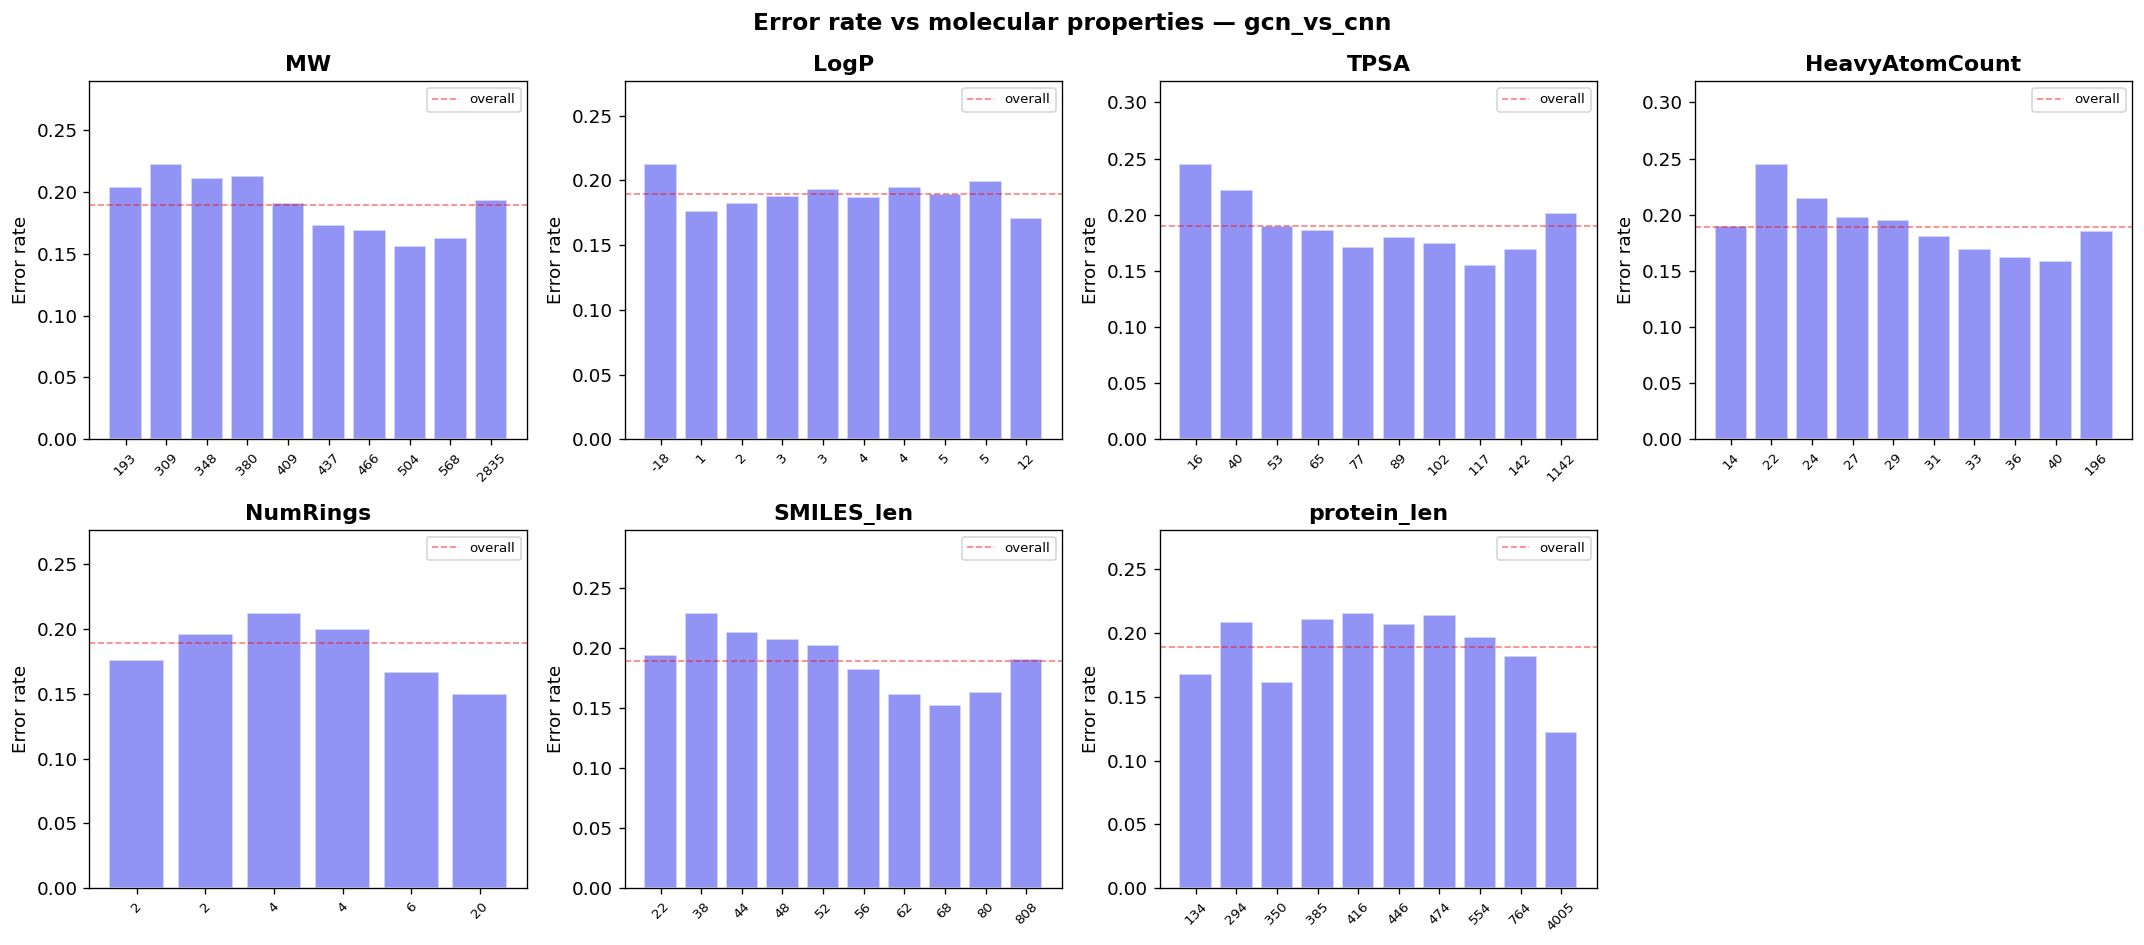

In [16]:
features_to_bin = ["MW", "LogP", "TPSA", "HeavyAtomCount", "NumRings", "SMILES_len", "protein_len"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feat in zip(axes.flat, features_to_bin):
    # Create bins using quantiles to ensure roughly equal bin sizes
    valid = results.filter(pl.col(feat).is_not_null())
    vals = valid[feat].to_numpy()
    correct_col = valid["correct"].to_numpy()
    
    n_bins = 10
    bin_edges = np.percentile(vals, np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)  # remove duplicates
    
    bin_indices = np.digitize(vals, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, len(bin_edges) - 2)
    
    error_rates = []
    bin_centers = []
    bin_counts = []
    for i in range(len(bin_edges) - 1):
        mask = bin_indices == i
        if mask.sum() > 10:  # at least 10 samples
            error_rates.append(1 - correct_col[mask].mean())
            bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
            bin_counts.append(mask.sum())
    
    ax.bar(range(len(error_rates)), error_rates, color="#6366f1", alpha=0.7, edgecolor="white")
    ax.set_xticks(range(len(bin_centers)))
    ax.set_xticklabels([f"{c:.0f}" for c in bin_centers], rotation=45, fontsize=8)
    ax.set_ylabel("Error rate")
    ax.set_title(feat, fontweight="bold")
    ax.set_ylim(0, min(1.0, max(error_rates) * 1.3) if error_rates else 1.0)
    ax.axhline(y=(1 - results["correct"].mean()), color="red", linestyle="--",
               lw=1, alpha=0.5, label="overall")
    ax.legend(fontsize=8)

# Hide unused axes
for i in range(len(features_to_bin), len(axes.flat)):
    axes.flat[i].set_visible(False)

fig.suptitle(f"Error rate vs molecular properties — {MODEL_NAME}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 8. Analiza per białko — które białka są najtrudniejsze?

In [17]:
# Per-protein error analysis
protein_stats = (
    results
    .group_by("protein_seq")
    .agg([
        pl.col("correct").count().alias("n_samples"),
        pl.col("correct").mean().alias("accuracy"),
        pl.col("true_label").mean().alias("positive_rate"),
        pl.col("pred_prob").mean().alias("mean_pred_prob"),
        pl.col("pred_prob").std().alias("std_pred_prob"),
        (pl.col("category") == "FP").sum().alias("n_FP"),
        (pl.col("category") == "FN").sum().alias("n_FN"),
    ])
    .with_columns(
        pl.col("protein_seq").str.len_chars().alias("protein_len"),
    )
    .sort("accuracy")
)

print(f"Unique proteins in test set: {protein_stats.height}")
print(f"\nTop 15 najtrudniejszych białek (najniższa accuracy, min 5 samples):")
protein_stats.filter(pl.col("n_samples") >= 5).head(15).select(
    ["protein_len", "n_samples", "accuracy", "positive_rate", "n_FP", "n_FN"]
)

Unique proteins in test set: 2257

Top 15 najtrudniejszych białek (najniższa accuracy, min 5 samples):


protein_len,n_samples,accuracy,positive_rate,n_FP,n_FN
u32,u32,f64,f64,u32,u32
400,5,0.0,0.2,4,1
283,9,0.0,0.0,9,0
863,16,0.125,0.0,14,0
351,6,0.166667,0.833333,0,5
418,6,0.166667,1.0,0,5
…,…,…,…,…,…
1144,15,0.2,0.8,0,12
23,9,0.222222,0.111111,6,1
473,13,0.230769,0.769231,0,10


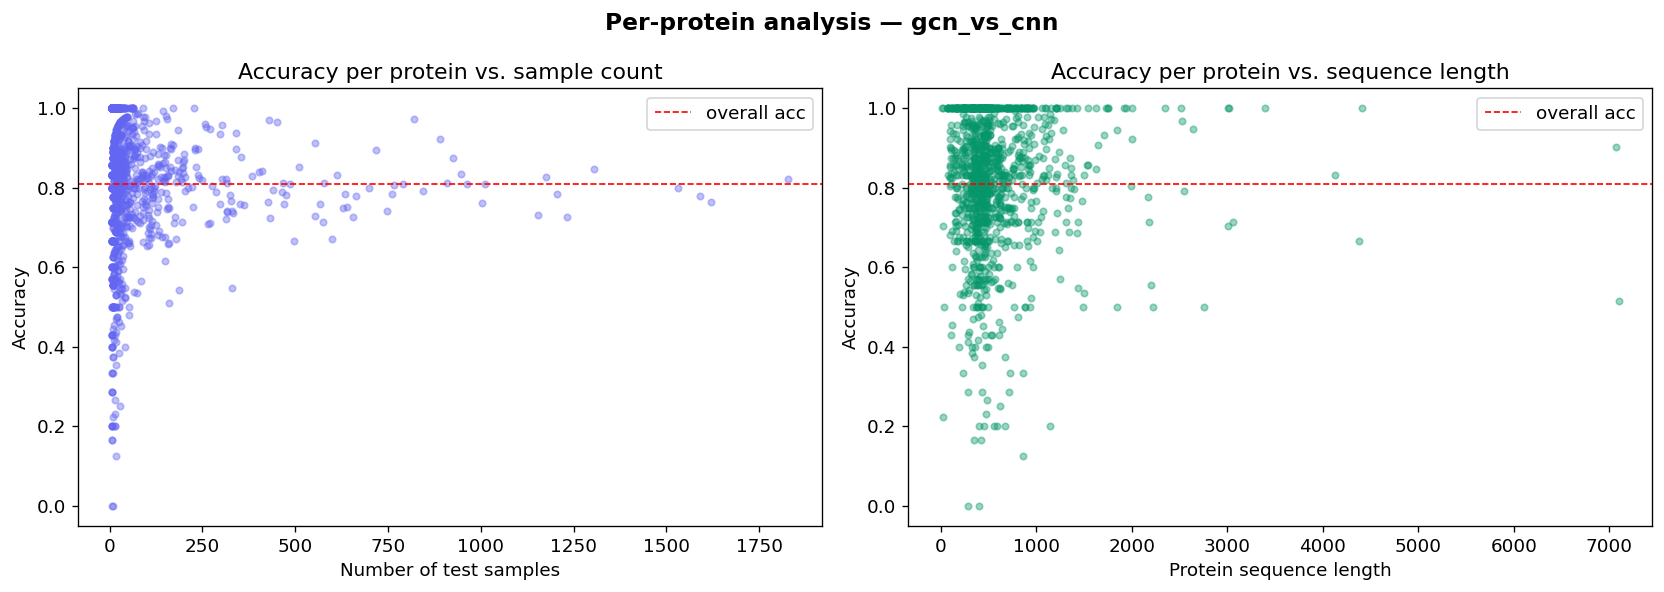

In [18]:
# Scatter: accuracy vs n_samples per protein
protein_min5 = protein_stats.filter(pl.col("n_samples") >= 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    protein_min5["n_samples"].to_numpy(),
    protein_min5["accuracy"].to_numpy(),
    alpha=0.4, s=15, c="#6366f1"
)
ax.set_xlabel("Number of test samples")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy per protein vs. sample count")
ax.axhline(y=results["correct"].mean(), color="red", linestyle="--", lw=1, label="overall acc")
ax.legend()

ax = axes[1]
ax.scatter(
    protein_min5["protein_len"].to_numpy(),
    protein_min5["accuracy"].to_numpy(),
    alpha=0.4, s=15, c="#059669"
)
ax.set_xlabel("Protein sequence length")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy per protein vs. sequence length")
ax.axhline(y=results["correct"].mean(), color="red", linestyle="--", lw=1, label="overall acc")
ax.legend()

fig.suptitle(f"Per-protein analysis — {MODEL_NAME}", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 9. Podsumowanie

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print(f"═══ Model: {MODEL_NAME} ═══")
print(f"Test samples:   {len(all_labels):,}")
print(f"Accuracy:       {(all_preds == all_labels).mean():.4f}")
print(f"AUC-ROC:        {roc_auc_score(all_labels, all_probs):.4f}")
print(f"AUPRC:          {average_precision_score(all_labels, all_probs):.4f}")
print(f"F1:             {f1_score(all_labels, all_preds):.4f}")
print()

# Summary of error patterns
for cat in ["TP", "TN", "FP", "FN"]:
    subset = results.filter(pl.col("category") == cat)
    n = subset.height
    pct = n / len(all_labels) * 100
    if n > 0:
        mw = subset["MW"].mean()
        logp = subset["LogP"].mean()
        rings = subset["NumRings"].mean()
        plen = subset["protein_len"].mean()
        print(f"{cat}: {n:>6,} ({pct:5.1f}%) | MW={mw:.0f}  LogP={logp:.1f}  Rings={rings:.1f}  ProtLen={plen:.0f}")

print()
print("Wnioski:")
print("- Porównaj średnie MW, LogP, NumRings między FP/FN a TP/TN")
print("- Jeśli FP/FN mają wyraźnie inny profil — model ma problemy z określonym typem cząsteczek")
print("- Sprawdź wykresy 'Error rate vs molecular properties' — wznoszące trendy wskazują słabe punkty")

═══ Model: gcn_vs_cnn ═══
Test samples:   90,103
Accuracy:       0.8105
AUC-ROC:        0.8925
AUPRC:          0.8925
F1:             0.8083

TP: 35,994 ( 39.9%) | MW=494  LogP=3.5  Rings=4.4  ProtLen=541
TN: 37,034 ( 41.1%) | MW=424  LogP=3.1  Rings=3.7  ProtLen=510
FP:  8,289 (  9.2%) | MW=472  LogP=3.2  Rings=4.0  ProtLen=494
FN:  8,786 (  9.8%) | MW=446  LogP=3.1  Rings=3.8  ProtLen=479

Wnioski:
- Porównaj średnie MW, LogP, NumRings między FP/FN a TP/TN
- Jeśli FP/FN mają wyraźnie inny profil — model ma problemy z określonym typem cząsteczek
- Sprawdź wykresy 'Error rate vs molecular properties' — wznoszące trendy wskazują słabe punkty
